In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/admin/Downloads/Netflix_Data(in).csv")

In [3]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s00001,Movie,Person Father,Anthony Chapman,United Kingdom,9/11/2018,2024,TV-MA,159 min,Romance
1,s00002,Movie,Church Difference,Dana Cruz,United States,12/4/2022,2002,TV-MA,65 min,Drama
2,s00003,TV Show,Rate Store,Kathleen Harris,South Korea,9/12/2018,2022,TV-14,2 Seasons,Sci-Fi
3,s00004,TV Show,Guess Air,Martin Richardson,United Kingdom,12/8/2024,2017,PG-13,2 Seasons,Romance
4,s00005,Movie,Clearly Back,NaN,South Korea,2/21/2019,2024,PG,67 min,"Romance, Comedy"


In [4]:
df.shape

(5100, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5100 non-null   object
 1   type          5100 non-null   object
 2   title         5100 non-null   object
 3   director      4362 non-null   object
 4   country       4685 non-null   object
 5   date_added    5100 non-null   object
 6   release_year  5100 non-null   int64 
 7   rating        5100 non-null   object
 8   duration      5100 non-null   object
 9   listed_in     5100 non-null   object
dtypes: int64(1), object(9)
memory usage: 398.6+ KB


In [6]:
df.describe()

,release_year
count,5100.000000
mean,2007.931176
std,10.619568
min,1990.000000
25%,1999.000000
50%,2008.000000
75%,2017.000000
max,2026.000000


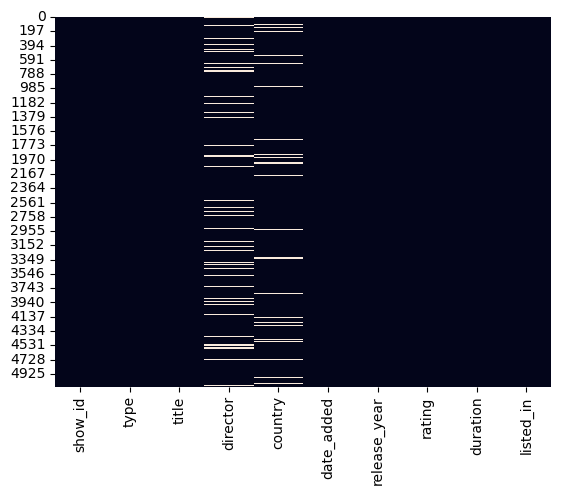

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [8]:
df.isnull().sum()

show_id           0
type              0
title             0
director        738
country         415
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
dtype: int64

In [9]:
df['director'] = df['director'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [12]:
cols=['type','country','rating']

for col in cols:
    df[col]=df[col].str.strip()

In [13]:
df['year_added']=df['date_added'].dt.year
df['month_added']=df['date_added'].dt.month

In [14]:
df['type'].value_counts()

type
TV Show    2534
Movie      2466
Name: count, dtype: int64

In [15]:
df['country'].value_counts().head(10)

country
Canada            804
United Kingdom    786
South Korea       776
United States     752
Japan             747
India             726
Unknown           409
Name: count, dtype: int64

In [16]:
df['listed_in'].value_counts().head(10)

listed_in
Documentary            228
Horror                 224
Action                 224
Drama                  220
Romance                213
Sci-Fi                 209
Comedy                 203
Thriller               197
Thriller, Drama         44
Documentary, Action     43
Name: count, dtype: int64

In [17]:
df['rating'].value_counts()

rating
TV-Y     742
TV-14    723
PG-13    718
R        714
PG       712
G        709
TV-MA    682
Name: count, dtype: int64

In [18]:
df.groupby('release_year').size()

release_year
1990    120
1991    121
1992    141
1993    150
1994    132
1995    143
1996    116
1997    143
1998    131
1999    130
2000    153
2001    125
2002    148
2003    135
2004    144
2005    143
2006    135
2007    152
2008    143
2009    149
2010    141
2011    138
2012    137
2013    127
2014    105
2015    125
2016    128
2017    136
2018    132
2019    141
2020    117
2021    144
2022    149
2023    121
2024    129
2025    134
2026    142
dtype: int64

In [19]:
df['director'].value_counts().head(10)

director
Unknown              721
Michael Johnson        7
Michael Rodriguez      4
Michael Thomas         3
Sarah Hill             3
Matthew Reed           3
Jennifer Miller        3
David Lewis            3
Michael Wilson         3
Thomas Johnson         3
Name: count, dtype: int64

In [20]:
df.groupby('year_added').size()

year_added
2018    362
2019    591
2020    637
2021    626
2022    654
2023    650
2024    592
2025    612
2026    276
dtype: int64

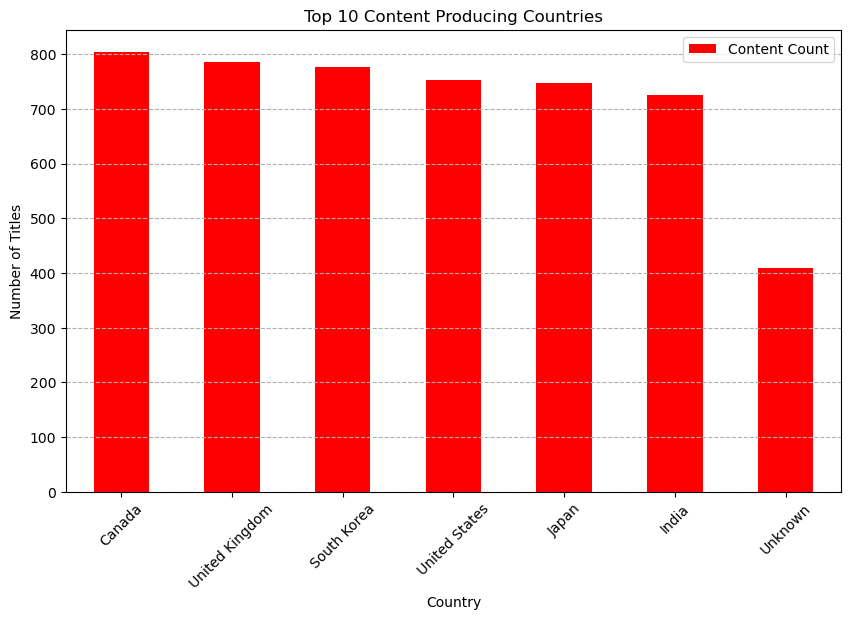

In [21]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_country.plot(
    kind='bar',
    color='Red'
)

plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--')

plt.legend(['Content Count'])

plt.show()

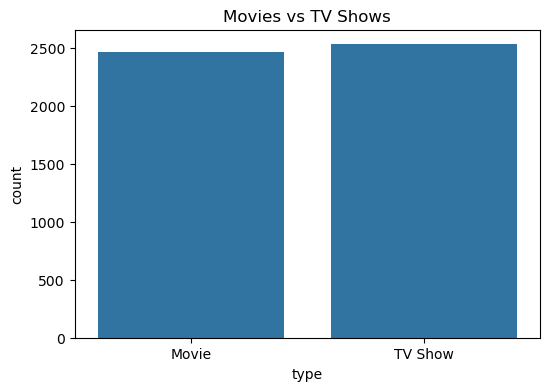

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x='type')

plt.title('Movies vs TV Shows')

plt.show()

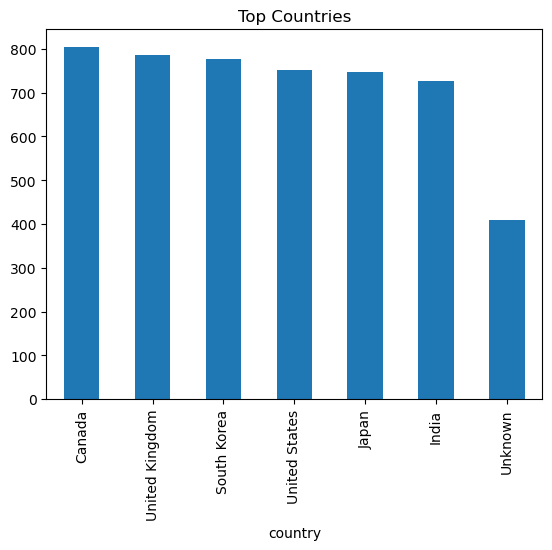

In [23]:
top_country=df['country'].value_counts().head(10)

top_country.plot(kind='bar')

plt.title('Top Countries')

plt.show()

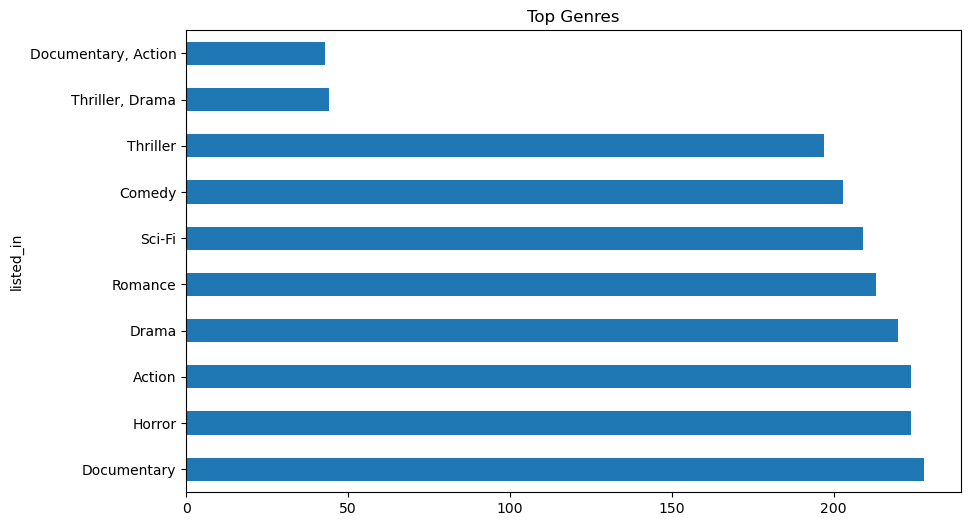

In [24]:
genre=df['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,6))

genre.plot(kind='barh')

plt.title('Top Genres')

plt.show()

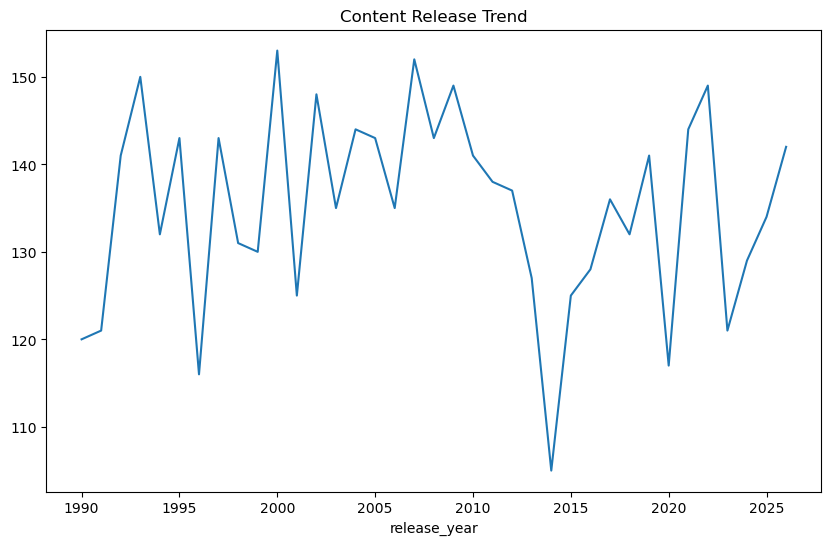

In [26]:
release=df.groupby('release_year').size()

plt.figure(figsize=(10,6))

release.plot()

plt.title('Content Release Trend')

plt.show()

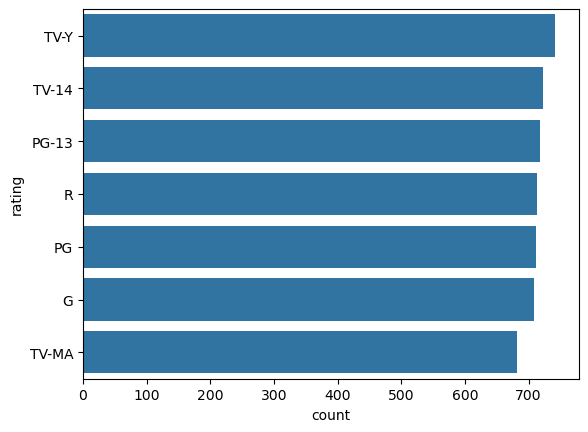

<Figure size 1000x600 with 0 Axes>

In [27]:
sns.countplot(data=df,
              y='rating',
              order=df['rating'].value_counts().index)

plt.figure(figsize=(10,6))

plt.show()

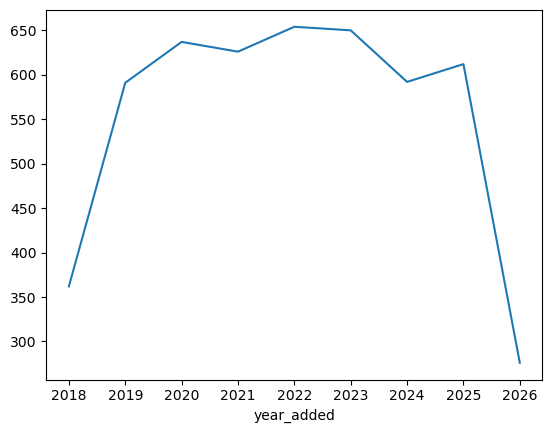

In [28]:
year_add=df.groupby('year_added').size()

sns.lineplot(x=year_add.index,
             y=year_add.values)

plt.show()